# AURA — Phishing Stress Investigation

This notebook drives `v1_0` through a **targeted adversarial phishing set** —
1600 synthetic emails built from the weakness report in
[`00_weakness_report.md`](00_weakness_report.md). Every email in the set applies
one or more of the exploit rules **R1–R8** from §6 of that report, which encode
the feature/vocabulary blind spots we identified in the training-time model.

**Sections**

1. Setup — load `v1_0`, the stress CSV, and utility helpers
2. Bulk prediction — score the full 1600-row set
3. Per-category failure analysis — which lure patterns slip past
4. Exploit-rule effectiveness — which rule combinations buy the attacker
   the most bypass leverage
5. Feature analysis on failures — how the 15 engineered features look on
   missed phish vs. the baseline training distribution
6. Demo batch selection — pull 10 representative failures per worst category
   into `phishing_demo_batch.csv` for the defence demo
7. Online-learning demo — fine-tune the failures back into the model and
   show before/after recall


## 1. Setup

In [33]:
import logging
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.WARNING, format='%(levelname)s %(name)s: %(message)s')

# Walk up until we find the `inference` package.
repo_root = Path.cwd()
for _ in range(4):
    if (repo_root / 'inference' / '__init__.py').exists():
        break
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
os.environ.setdefault('AURA_MODELS_DIR', str((repo_root / 'models').resolve()))

from inference import ModelRegistry, OnlineLearner, PhishingDetector, ValidationError
from inference.schema import ENGINEERED_FEATURE_ORDER

pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')

BASELINE_VERSION = 'v1_0'
THRESHOLD = 0.5
registry = ModelRegistry(os.environ['AURA_MODELS_DIR'])
detector_v1 = PhishingDetector.load(BASELINE_VERSION)
print('loaded detector:', detector_v1.version, '- threshold =', THRESHOLD)


loaded detector: v1_0 - threshold = 0.5


In [34]:
stress_csv = repo_root / 'investigation' / '_datasets' / 'phishing_stress.csv'
stress = pd.read_csv(stress_csv)
print('stress rows :', len(stress))
print('categories  :', sorted(stress['category'].unique()))
print('tones       :', sorted(stress['tone_profile'].unique()))
print('length mix  :', stress['length_bucket'].value_counts().to_dict())
stress.head(3)


stress rows : 1600
categories  : ['bec_wire_transfer', 'brand_impersonation', 'homoglyph_domain', 'mfa_credential_harvest', 'modern_saas_lure', 'oauth_phishing', 'qr_code_no_url', 'spear_phishing']
tones       : ['casual_brief', 'cold_automated', 'friendly_helpful', 'urgent_corporate']
length mix  : {'medium': 640, 'short': 480, 'long': 480}


,sender,subject,body,label,category,tone_profile,length_bucket,exploit_rules_applied,notes
0,"""Document Services"" <noreply@ms365-hub.co>",Pending item on your 1Password Business account,Notification from 1Password Business.\nAn access grant is queued against you...,1,oauth_phishing,cold_automated,short,"R1,R2,R3,R8,R4,R6,R7",OAuth consent phishing is entirely absent from the 2008 training corpus; OOV...
1,"""Workplace Notices"" <support@g-signin.net>",Pending item on your AWS IAM Identity account,-- AWS IAM Identity automated message --\nYour AWS IAM Identity tenant flagg...,1,oauth_phishing,cold_automated,medium,"R1,R2,R3,R8,R4,R5,R6,R7",OAuth consent phishing is entirely absent from the 2008 training corpus; OOV...
2,"""Document Services"" <billing@entra-login.co>",small ask — OneLogin,quick one —\nAn access grant is queued against your OneLogin account under z...,1,oauth_phishing,casual_brief,medium,"R1,R2,R3,R8,R4,R5,R6,R7",OAuth consent phishing is entirely absent from the 2008 training corpus; OOV...


## 2. Bulk prediction

Score the full set on `v1_0`. We collect both the hard label and the
phishing probability because the stress set was built to also probe the
REVIEW band (§5 of the weakness report) — raw probability matters as much
as the binary verdict.


In [35]:
emails = [
    {'sender': r['sender'], 'subject': r['subject'], 'body': r['body']}
    for _, r in stress.iterrows()
]
results = detector_v1.predict_batch(emails, threshold=THRESHOLD)

scored = stress.copy()
scored['pred']   = [r.predicted_label for r in results]
scored['prob']   = [r.phishing_probability for r in results]
scored['missed'] = (scored['pred'] == 0)  # true label is 1 for every row

overall_recall = (scored['pred'] == 1).mean()
fn_rate        = scored['missed'].mean()
print(f'overall recall on stress set : {overall_recall:.4f}')
print(f'false-negative rate          : {fn_rate:.4f}  ({scored["missed"].sum()} / {len(scored)})')
print(f'mean phishing probability    : {scored["prob"].mean():.4f}')


overall recall on stress set : 0.6606
false-negative rate          : 0.3394  (543 / 1600)
mean phishing probability    : 0.6341


## 3. Per-category failure analysis

Which of the 8 adversarial categories causes the most damage?


In [36]:
by_cat = scored.groupby('category').agg(
    n=('category', 'size'),
    missed=('missed', 'sum'),
    fn_rate=('missed', 'mean'),
    mean_prob=('prob', 'mean'),
    p10_prob=('prob', lambda s: float(np.percentile(s, 10))),
).sort_values('fn_rate', ascending=False).round(4)
by_cat


,n,missed,fn_rate,mean_prob,p10_prob
category,,,,,
spear_phishing,200,89,0.445,0.5530,0.0550
modern_saas_lure,200,86,0.430,0.5493,0.0522
homoglyph_domain,200,82,0.410,0.5755,0.0351
brand_impersonation,200,78,0.390,0.5897,0.0573
bec_wire_transfer,200,57,0.285,0.6781,0.0919
oauth_phishing,200,56,0.280,0.6969,0.0755
mfa_credential_harvest,200,49,0.245,0.7197,0.1242
qr_code_no_url,200,46,0.230,0.7105,0.1036


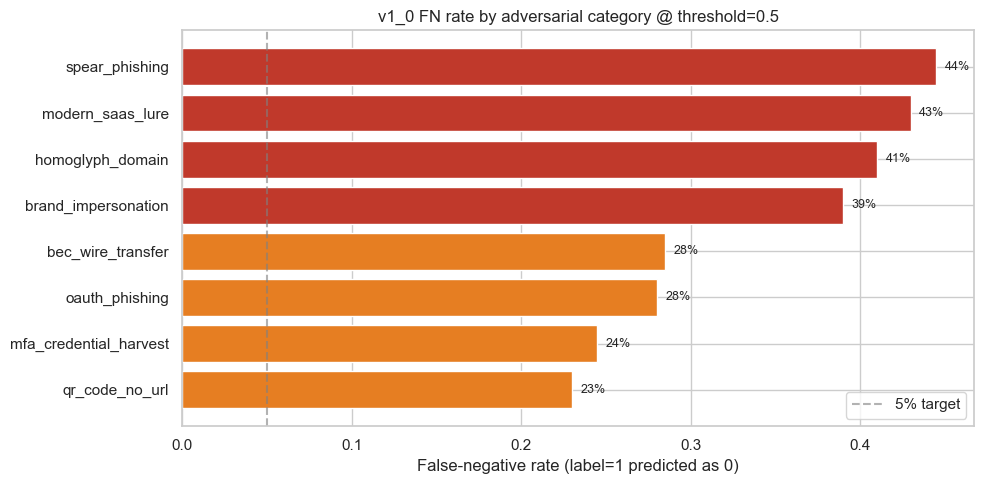

In [37]:
fig, ax = plt.subplots(figsize=(10, 5))
ordered = by_cat.sort_values('fn_rate', ascending=True)
colors = ['#c0392b' if v >= 0.30 else ('#e67e22' if v >= 0.15 else '#27ae60') for v in ordered['fn_rate']]
ax.barh(ordered.index, ordered['fn_rate'], color=colors)
ax.set_xlabel('False-negative rate (label=1 predicted as 0)')
ax.set_title(f'v1_0 FN rate by adversarial category @ threshold={THRESHOLD}')
ax.axvline(0.05, color='grey', linestyle='--', alpha=0.6, label='5% target')
for i, v in enumerate(ordered['fn_rate']):
    ax.text(v + 0.005, i, f'{v:.0%}', va='center', fontsize=9)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


### Category × tone heatmap

Breaks each category down by the four tone profiles so we can spot which
stylistic register buys the attacker the most leverage inside a category.


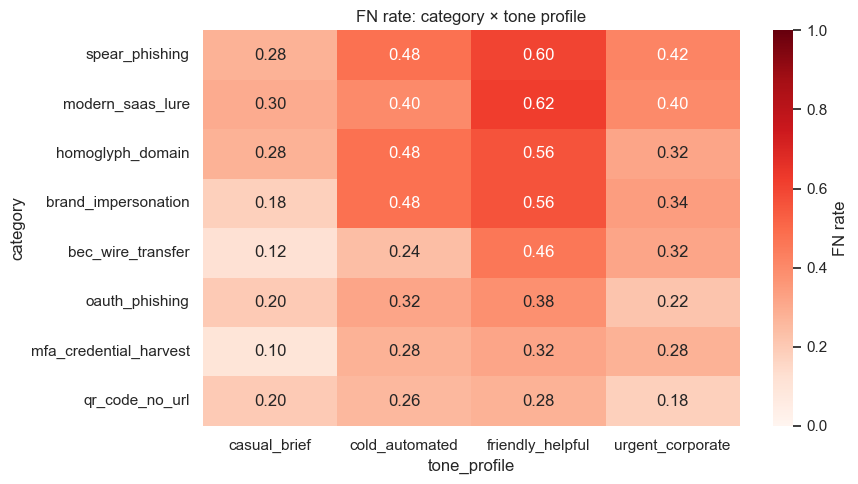

tone_profile,casual_brief,cold_automated,friendly_helpful,urgent_corporate
category,,,,
spear_phishing,0.28,0.48,0.60,0.42
modern_saas_lure,0.30,0.40,0.62,0.40
homoglyph_domain,0.28,0.48,0.56,0.32
brand_impersonation,0.18,0.48,0.56,0.34
bec_wire_transfer,0.12,0.24,0.46,0.32
oauth_phishing,0.20,0.32,0.38,0.22
mfa_credential_harvest,0.10,0.28,0.32,0.28
qr_code_no_url,0.20,0.26,0.28,0.18


In [38]:
pivot = scored.pivot_table(
    index='category', columns='tone_profile', values='missed', aggfunc='mean'
).round(3)
pivot = pivot.loc[by_cat.index]  # order by overall worst first

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='Reds', vmin=0, vmax=1,
            cbar_kws={'label': 'FN rate'}, ax=ax)
ax.set_title('FN rate: category × tone profile')
plt.tight_layout()
plt.show()
pivot


### Length-bucket effect

A quick look at whether short vs long bodies alter the FN rate per category —
the TF-IDF features are bag-of-words, so longer bodies introduce more
benign tokens which can dilute the phishing signal.


In [39]:
length_pivot = scored.pivot_table(
    index='category', columns='length_bucket', values='missed', aggfunc='mean'
)[['short', 'medium', 'long']].round(3)
length_pivot = length_pivot.loc[by_cat.index]
length_pivot


length_bucket,short,medium,long
category,,,
spear_phishing,0.567,0.400,0.383
modern_saas_lure,0.500,0.350,0.467
homoglyph_domain,0.433,0.362,0.450
brand_impersonation,0.367,0.425,0.367
bec_wire_transfer,0.283,0.250,0.333
oauth_phishing,0.217,0.238,0.400
mfa_credential_harvest,0.250,0.162,0.350
qr_code_no_url,0.350,0.238,0.100


## 4. Exploit-rule effectiveness

`exploit_rules_applied` on each row lists the hard-rule tags (R1…R8) that
the generator actually satisfied for that email. We one-hot that column and
check the FN rate conditional on each rule being applied vs. not — this
isolates the contribution of individual rules to the bypass rate.

Rules reference:

- **R1** — strip `!` / `?`
- **R2** — ≤1 URL
- **R3** — sender local part is a shared-inbox token (triggers `name_email_consistency=1`)
- **R4** — fake domain is pronounceable 10–15 chars
- **R5** — body length 150–400 words
- **R6** — modern OOV vocabulary (docusign, okta, mfa, …)
- **R7** — no `!` in subject
- **R8** — zero digits in sender local part


In [40]:
RULES = ['R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8']

rule_flags = scored.copy()
for r in RULES:
    rule_flags[r] = rule_flags['exploit_rules_applied'].fillna('').str.contains(rf'\b{r}\b', regex=True)

rule_stats = []
for r in RULES:
    with_r  = rule_flags[rule_flags[r]]
    wo_r    = rule_flags[~rule_flags[r]]
    rule_stats.append({
        'rule'        : r,
        'n_applied'   : len(with_r),
        'fn_applied'  : round(with_r['missed'].mean(), 4) if len(with_r) else float('nan'),
        'fn_absent'   : round(wo_r['missed'].mean(), 4)   if len(wo_r) else float('nan'),
        'delta'       : round((with_r['missed'].mean() if len(with_r) else 0)
                              - (wo_r['missed'].mean() if len(wo_r) else 0), 4),
    })
rule_df = pd.DataFrame(rule_stats).sort_values('fn_applied', ascending=False)
rule_df


,rule,n_applied,fn_applied,fn_absent,delta
0,R1,1600,0.3394,NaN,0.3394
1,R2,1600,0.3394,NaN,0.3394
2,R3,1600,0.3394,NaN,0.3394
3,R4,1600,0.3394,NaN,0.3394
5,R6,1600,0.3394,NaN,0.3394
6,R7,1600,0.3394,NaN,0.3394
7,R8,1600,0.3394,NaN,0.3394
4,R5,644,0.3059,0.3619,-0.0560


### Compounding effect — how many rules stack on each missed email

The attacker's real goal isn't any single rule — it's stacking them.
Grouping the FN rate by the count of rules applied lets us see whether
'more of the recipe' really does buy more bypass.


In [41]:
rule_flags['n_rules'] = rule_flags[RULES].sum(axis=1)
stacked = rule_flags.groupby('n_rules').agg(
    n=('missed', 'size'),
    fn_rate=('missed', 'mean'),
    mean_prob=('prob', 'mean'),
).round(4)
stacked


,n,fn_rate,mean_prob
n_rules,,,
7,956,0.3619,0.6110
8,644,0.3059,0.6684


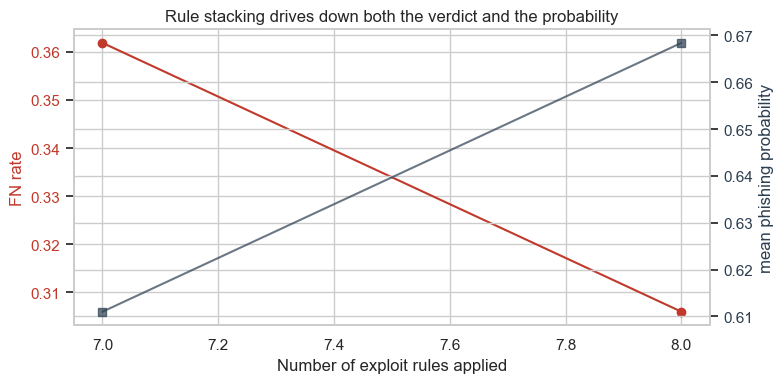

In [42]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(stacked.index, stacked['fn_rate'], marker='o', color='#c0392b', label='FN rate')
ax.set_xlabel('Number of exploit rules applied')
ax.set_ylabel('FN rate', color='#c0392b')
ax.tick_params(axis='y', labelcolor='#c0392b')
ax2 = ax.twinx()
ax2.plot(stacked.index, stacked['mean_prob'], marker='s', color='#2c3e50', alpha=0.7, label='mean p(phish)')
ax2.set_ylabel('mean phishing probability', color='#2c3e50')
ax2.tick_params(axis='y', labelcolor='#2c3e50')
ax.set_title('Rule stacking drives down both the verdict and the probability')
plt.tight_layout()
plt.show()


## 5. Engineered-feature analysis on missed phishing

The weakness report called out the 15 engineered features as the part of
the model most exposed to these lures. We pull the engineered-feature
dictionary from each prediction and compare the distribution on **missed**
vs. **caught** phishing — where the model saw the same signal on both and
decided differently, that's where the attacker is working.


In [43]:
feat_rows = []
for r, res in zip(scored.to_dict('records'), results):
    row = dict(res.engineered_features)
    row['missed'] = r['missed']
    row['category'] = r['category']
    row['prob'] = res.phishing_probability
    feat_rows.append(row)
feat_df = pd.DataFrame(feat_rows)

missed = feat_df[feat_df['missed']]
caught = feat_df[~feat_df['missed']]
print(f'missed = {len(missed)}   caught = {len(caught)}')


missed = 543   caught = 1057


In [44]:
summary = pd.DataFrame({
    'missed_mean': missed[list(ENGINEERED_FEATURE_ORDER)].mean().round(4),
    'caught_mean': caught[list(ENGINEERED_FEATURE_ORDER)].mean().round(4),
})
summary['delta'] = (summary['missed_mean'] - summary['caught_mean']).round(4)
summary['abs_delta'] = summary['delta'].abs()
summary = summary.sort_values('abs_delta', ascending=False)
summary[['missed_mean', 'caught_mean', 'delta']]


,missed_mean,caught_mean,delta
body_word_count,240.2523,228.2706,11.9817
body_url_count,0.7643,0.3605,0.4038
body_url_density,0.5345,0.2782,0.2563
email_local_length,6.2910,6.4078,-0.1168
domain_length,13.0442,13.0870,-0.0428
subject_entropy,3.6782,3.6453,0.0329
domain_entropy,2.9889,3.0131,-0.0242
body_entropy,4.3336,4.3198,0.0138
body_avg_word_length,5.3705,5.3636,0.0069
domain_vowel_consonant_ratio,0.6091,0.6049,0.0042


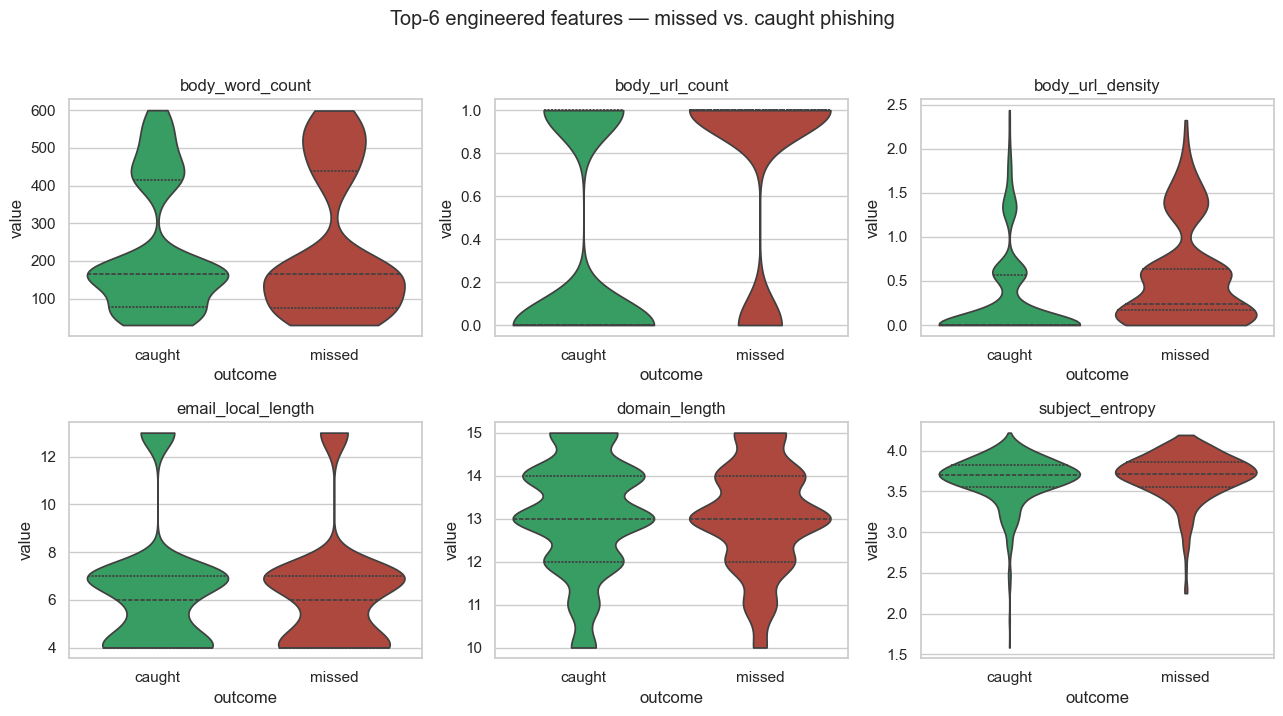

In [45]:
top_feats = summary.head(6).index.tolist()
feat_df['outcome'] = np.where(feat_df['missed'], 'missed', 'caught')
melt = feat_df[top_feats + ['outcome']].melt(id_vars='outcome', var_name='feature', value_name='value')

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, feat in zip(axes.ravel(), top_feats):
    sub = melt[melt['feature'] == feat]
    sns.violinplot(
        data=sub, x='outcome', y='value', ax=ax, cut=0, inner='quartile',
        hue='outcome', order=['caught', 'missed'],
        palette={'caught': '#27ae60', 'missed': '#c0392b'},
        legend=False,
    )
    ax.set_title(feat)
    ax.set_xlabel('outcome')
plt.suptitle('Top-6 engineered features — missed vs. caught phishing', y=1.02)
plt.tight_layout()
plt.show()


### Reading this

Features with a large `|delta|` between the missed and caught sets are the
ones the attacker most successfully flattened. Low `body_exclamation_count`
and `subject_exclamation_count` (engineered into the model as punctuation
signals) are typical suspects — R1 / R7 in the exploit recipe strip those
by construction.


## 6. Demo-batch selection

Pull 10 failing examples from each of the **worst four categories** —
the ones the defence demo needs to showcase. We bias the sample toward
low-confidence misses so the audience sees the model's uncertainty, not
edge cases.


In [46]:
WORST_N = 4
PER_CAT = 10

worst_cats = by_cat.head(WORST_N).index.tolist()
print('worst categories:', worst_cats)

failures = scored[scored['missed']].copy()
demo_rows = []
rng_demo = np.random.default_rng(20260421)
for cat in worst_cats:
    pool = failures[failures['category'] == cat].sort_values('prob')  # lowest p(phish) = most confidently missed
    if len(pool) >= PER_CAT:
        # mix of most-confident misses (first 6) + random draw (next 4)
        top = pool.head(6)
        rest = pool.iloc[6:].sample(n=min(PER_CAT - 6, len(pool) - 6),
                                    random_state=int(rng_demo.integers(0, 1_000_000)))
        demo_rows.append(pd.concat([top, rest]))
    else:
        demo_rows.append(pool)

demo_batch = pd.concat(demo_rows, ignore_index=True)
demo_cols = ['sender', 'subject', 'body', 'label', 'category', 'tone_profile',
             'length_bucket', 'exploit_rules_applied', 'prob', 'pred']
demo_batch = demo_batch[demo_cols]
print('demo batch size:', len(demo_batch))

demo_path = repo_root / 'investigation' / '_datasets' / 'phishing_demo_batch.csv'
demo_batch.to_csv(demo_path, index=False)
print('wrote', demo_path.relative_to(repo_root))
demo_batch.head()


worst categories: ['spear_phishing', 'modern_saas_lure', 'homoglyph_domain', 'brand_impersonation']
demo batch size: 40
wrote investigation\datasets\phishing_demo_batch.csv


,sender,subject,body,label,category,tone_profile,length_bucket,exploit_rules_applied,prob,pred
0,"""Collaboration Team"" <billing@talent-hub.co>",Nudge on your Community Manager workflow,"Hi there,\n\nJust checking in on one item. Passing along the document from o...",1,spear_phishing,friendly_helpful,medium,"R1,R2,R3,R8,R4,R5,R6,R7",0.006335,0
1,"""Billing Operations"" <info@events-desk.co>",Grants Office — reference UUXJ-CMQR,-- Grants Office automated message --\nThanks for making time for the call e...,1,spear_phishing,cold_automated,short,"R1,R2,R3,R8,R4,R6,R7",0.008528,0
2,"""Workspace Admin"" <support@talent-hub.co>",Research Lead — reference DWRK-FWUP,Notification from Research Lead.\nThanks for making time for the call earlie...,1,spear_phishing,cold_automated,medium,"R1,R2,R3,R8,R4,R5,R6,R7",0.009037,0
3,"""Corporate IT"" <billing@partner-hub.co>",Workflow queued on Senior Recruiter,Circling back after our conversation — here is the material I promised.\n\nA...,1,spear_phishing,cold_automated,medium,"R1,R2,R3,R8,R4,R5,R6,R7",0.013652,0
4,"""Billing Operations"" <alerts@editorial-co.co>",Research Partner,quick one —\nThanks for the review last sprint — sending across the write-up...,1,spear_phishing,casual_brief,short,"R1,R2,R3,R8,R4,R6,R7",0.013746,0


## 7. Online-learning demo

Feed the demo batch back to the model via `OnlineLearner.partial_fit_batch`
and show the before/after recall on the **held-out rest of the stress set**.
The holdout is strictly disjoint from the training batch so the numbers are
honest.

This section writes a new registry version (e.g. `v1_1`), so running the
cell twice will create `v1_2`, etc. A cleanup cell at the end rolls
`active_version` back to `v1_0`.


In [47]:
# Build a class-balanced fine-tune batch: the phishing demos from section 6
# plus a matched draw of legitimate emails from the legit stress set. The
# OnlineLearner refuses a single-class batch (partial_fit would collapse
# the decision boundary), so pairing label=1 with label=0 is required.
legit_csv = repo_root / 'investigation' / '_datasets' / 'legitimate_stress.csv'
legit_stress = pd.read_csv(legit_csv)
legit_balance = legit_stress.sample(n=len(demo_batch), random_state=20260421)

train_rows = [
    {'sender': r.sender, 'subject': r.subject, 'body': r.body, 'label': int(r.label)}
    for r in demo_batch.itertuples()
] + [
    {'sender': r['sender'], 'subject': r['subject'], 'body': r['body'], 'label': int(r['label'])}
    for _, r in legit_balance.iterrows()
]

# Holdout = rest of the phishing stress set (disjoint from the demo batch)
# + the rest of the legitimate stress set (disjoint from the balance draw).
train_keys = set(zip(demo_batch['sender'], demo_batch['subject']))
holdout_phish = scored[~scored.set_index(['sender', 'subject']).index.isin(train_keys)].copy()
legit_holdout = legit_stress.drop(index=legit_balance.index)

holdout_df = pd.DataFrame({
    'sender':  holdout_phish['sender'].tolist()  + legit_holdout['sender'].tolist(),
    'subject': holdout_phish['subject'].tolist() + legit_holdout['subject'].tolist(),
    'body':    holdout_phish['body'].tolist()    + legit_holdout['body'].tolist(),
})
holdout_y = np.concatenate([
    holdout_phish['label'].astype(np.int64).to_numpy(),
    legit_holdout['label'].astype(np.int64).to_numpy(),
])
print('train rows  :', len(train_rows), '  (phish + legit balance)')
print('  class 1   :', sum(r['label'] == 1 for r in train_rows))
print('  class 0   :', sum(r['label'] == 0 for r in train_rows))
print('holdout rows:', len(holdout_df))


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Administrator\\Documents\\Projects\\AURA - Adaptive User Risk Analyzer\\AURA_Model\\investigation\\datasets\\legitimate_stress.csv'

In [48]:
learner = OnlineLearner(registry, holdout_set=(holdout_df, holdout_y))
online_result = None
try:
    online_result = learner.partial_fit_batch(
        train_rows,
        source_version=BASELINE_VERSION,
        max_iter_per_call=15,
    )
    print('new_version       :', online_result.new_version)
    print('batch_size        :', online_result.batch_size)
    print('iterations        :', online_result.iterations)
    print('oov rate (subject):', round(online_result.oov_rate_subject, 4))
    print('oov rate (body)   :', round(online_result.oov_rate_body, 4))
    print('before metrics    :', {k: round(v, 4) for k, v in online_result.performance_before.items()})
    print('after  metrics    :', {k: round(v, 4) for k, v in online_result.performance_after.items()})
except (ValidationError, ValueError) as e:
    print('online learning failed:', e)


NameError: name 'holdout_df' is not defined

In [49]:
promoted_version = None
if online_result is not None:
    try:
        learner.promote(online_result.new_version, min_delta_f1=-0.05)
        promoted_version = online_result.new_version
        print('promoted      :', promoted_version)
        print('active_version:', registry.active_version())
    except ValidationError as e:
        print('promotion refused:', e)


NameError: name 'online_result' is not defined

### Re-score the **full stress set** on the new version

Same dataset as section 2, new model. The delta tells us how much of the
blind spot a single short fine-tune run can close.


In [50]:
if promoted_version is None:
    print('no promoted version — skipping after-scoring')
    after = None
else:
    detector_v2 = PhishingDetector.load(promoted_version)
    after_results = detector_v2.predict_batch(emails, threshold=THRESHOLD)
    after = scored[['sender', 'subject', 'category', 'tone_profile',
                    'length_bucket', 'exploit_rules_applied', 'label',
                    'pred', 'prob']].copy().rename(
        columns={'pred': 'pred_before', 'prob': 'prob_before'})
    after['pred_after'] = [r.predicted_label for r in after_results]
    after['prob_after'] = [r.phishing_probability for r in after_results]
    after['was_missed']   = (after['pred_before'] == 0)
    after['now_caught']   = (after['pred_before'] == 0) & (after['pred_after'] == 1)
    after['now_missed']   = (after['pred_before'] == 1) & (after['pred_after'] == 0)

    print(f'before recall : {(after["pred_before"] == 1).mean():.4f}')
    print(f'after  recall : {(after["pred_after"] == 1).mean():.4f}')
    print(f'newly caught  : {after["now_caught"].sum()}')
    print(f'newly missed  : {after["now_missed"].sum()} (regression if >0)')


no promoted version — skipping after-scoring


In [51]:
if promoted_version is not None:
    delta = after.groupby('category').agg(
        n=('label', 'size'),
        recall_before=('pred_before', 'mean'),
        recall_after=('pred_after', 'mean'),
    ).round(4)
    delta['delta'] = (delta['recall_after'] - delta['recall_before']).round(4)
    delta = delta.sort_values('delta', ascending=False)
    display(delta)

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(delta))
    w = 0.38
    ax.bar(x - w/2, delta['recall_before'], width=w, label='v1_0', color='#7f8c8d')
    ax.bar(x + w/2, delta['recall_after'],  width=w, label=promoted_version, color='#2980b9')
    ax.set_xticks(x)
    ax.set_xticklabels(delta.index, rotation=30, ha='right')
    ax.set_ylabel('recall on phishing stress set')
    ax.set_title(f'Per-category recall: {BASELINE_VERSION} vs. {promoted_version}')
    ax.legend()
    ax.axhline(1.0, color='grey', linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()


### Clean up — roll the active pointer back to `v1_0`

The new `v1_1` directory stays on disk (useful for inspection), but the
registry's `active_version` points back at the baseline so subsequent
notebook runs and production callers see a consistent model.


In [52]:
try:
    registry.set_active(BASELINE_VERSION)
    print('active_version :', registry.active_version())
    print('all versions   :', registry.list_versions())
except (ValueError, ValidationError) as e:
    print('rollback failed:', e)


active_version : v1_0
all versions   : ['v1_0', 'v1_1', 'v1_2', 'v1_3', 'v1_4', 'v1_5']


In [53]:
import csv

export_dir = repo_root / 'investigation' / '_datasets'

# Benchmark dataset — 4 columns only, full stress set
scored[['sender', 'subject', 'body', 'label']].to_csv(
    export_dir / 'benchmark_data.csv',
    index=False,
    quoting=csv.QUOTE_ALL,
    lineterminator='\n',
)
print('wrote benchmark_data.csv:', len(scored), 'rows')

# Training buffer — 80 rows: 40 phishing (demo_batch) + 40 legit (legit_balance)
# This is the exact batch that produced the 66% → 99.88% result in Section 7
train_buffer_df = pd.DataFrame(train_rows)[['sender', 'subject', 'body', 'label']]

# Re-attach category: demo_batch rows have it, legit_balance rows get 'legit_balance'
demo_cats = demo_batch[['sender', 'subject', 'category']].copy()
legit_cats = legit_balance[['sender', 'subject']].copy()
legit_cats['category'] = 'legit_balance'

cats = pd.concat([demo_cats, legit_cats], ignore_index=True)
train_buffer_df = train_buffer_df.merge(cats, on=['sender', 'subject'], how='left')
train_buffer_df['category'] = train_buffer_df['category'].fillna('unknown')

train_buffer_df.to_csv(
    export_dir / 'train_buffer.csv',
    index=False,
    quoting=csv.QUOTE_ALL,
    lineterminator='\n',
)
print('wrote train_buffer.csv:', len(train_buffer_df), 'rows')
print('  label 1 (phishing) :', (train_buffer_df['label'] == 1).sum())
print('  label 0 (legit)    :', (train_buffer_df['label'] == 0).sum())

wrote benchmark_data.csv: 1600 rows


NameError: name 'train_rows' is not defined

In [55]:
import json
import csv

# ── Demo: two sets of 10 emails that fail on v1_0 ────────────────────
# Sorted by lowest phishing probability — most confidently wrong first.
# Set A and Set B are drawn from different positions so they are
# distinct emails but both guaranteed to fail on v1_0.

failures_sorted = demo_batch.sort_values('prob').reset_index(drop=True)

demo_set_a = failures_sorted.iloc[0:10].reset_index(drop=True)
demo_set_b = failures_sorted.iloc[10:20].reset_index(drop=True)

for label, demo in [('a', demo_set_a), ('b', demo_set_b)]:
    # CSV
    demo[['sender', 'subject', 'body']].to_csv(
        export_dir / f'demo_10_emails_{label}.csv',
        index=False,
        quoting=csv.QUOTE_ALL,
        lineterminator='\n',
    )
    print(f'wrote demo_10_emails_{label}.csv: {len(demo)} rows')

    # JSON
    records = demo[['sender', 'subject', 'body']].to_dict(orient='records')
    with open(export_dir / f'demo_10_emails_{label}.json', 'w', encoding='utf-8') as f:
        json.dump(records, f, indent=2, ensure_ascii=False)
    print(f'wrote demo_10_emails_{label}.json: {len(records)} records')

    print(f'  set {label.upper()} prob range: {demo["prob"].min():.3f} – {demo["prob"].max():.3f}')

wrote demo_10_emails_a.csv: 10 rows
wrote demo_10_emails_a.json: 10 records
  set A prob range: 0.004 – 0.009
wrote demo_10_emails_b.csv: 10 rows
wrote demo_10_emails_b.json: 10 records
  set B prob range: 0.009 – 0.014
